In [ ]:
# IMPORTS - All standard libraries used throughout this notebook
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image, UnidentifiedImageError  # For image verification

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    BatchNormalization, Dropout, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16

from sklearn.metrics import classification_report  # For Task-2 evaluation

print("TensorFlow version:", tf.__version__)
print("All imports successful!")

TensorFlow version: 2.19.0
All imports successful!


In [ ]:
import zipfile

with zipfile.ZipFile("/content/FruitinAmazon.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:
# STEP 1: Read the Dataset Directory & Extract Class Names
#
# Each sub-folder inside train_dir represents one class.
# Sort the list so that the class index is always consistent.
train_dir = "/content/FruitinAmazon/train"

# Get class names (sub-directory names)
class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
# STEP 2: Check for Corrupted Images
#
# Real-world datasets often contain corrupted or partially
# downloaded files. Using PIL's img.verify() we detect them.
# Corrupted files are logged and then deleted from disk.

corrupted_images = []  # List to store paths of corrupted images

# Loop through every class folder
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):  # Ensure it is a valid directory
        images = os.listdir(class_path)

        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()  # verify() checks the file header only
                                  # - it does NOT fully decode the image
            except (IOError, UnidentifiedImageError):
                # If an exception occurs, the image is corrupted
                corrupted_images.append(img_path)

# Report results
if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
        os.remove(img)  # Remove corrupted file from disk
    print(f"\nRemoved {len(corrupted_images)} corrupted image(s).")
else:
    print("\nNo corrupted images found.")


No corrupted images found.


In [ ]:
# STEP 3: Count Class Balance (Class Distribution)
#
# A balanced dataset is crucial - if one class has far more
# images than others, the model may become biased toward it.
# Count valid image files (.png, .jpg, .jpeg) per class.

class_counts = {}  # Dictionary: class_name - image count

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        # Only count files with valid image extensions
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        class_counts[class_name] = len(images)

# Pretty-print the class distribution table
print("\nClass Distribution:")
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


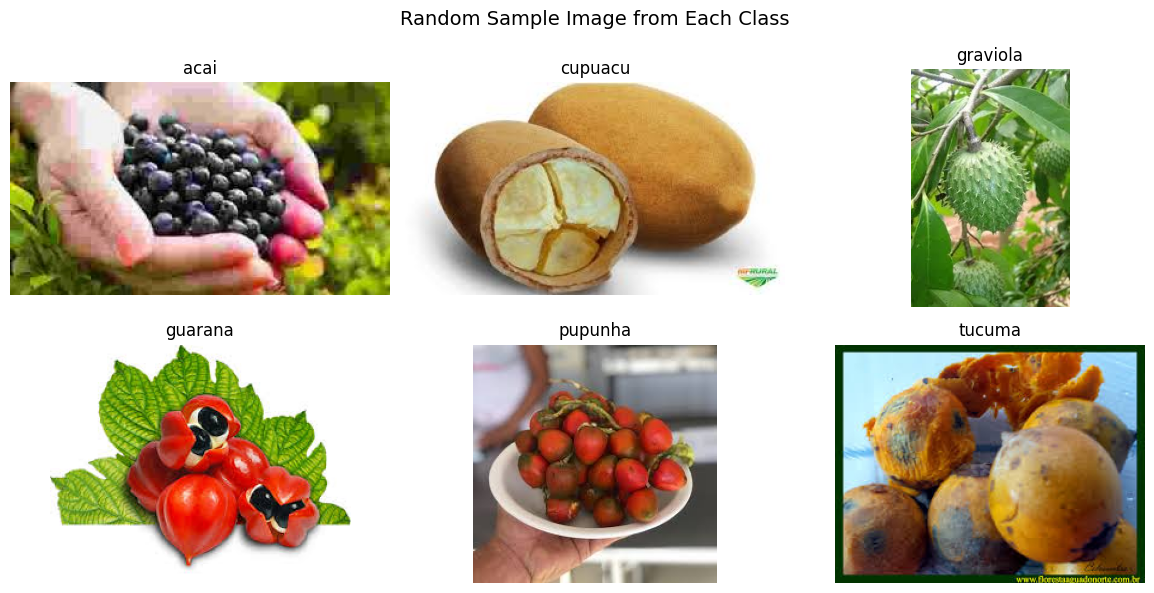

In [ ]:
# STEP 4: Select & Visualize Random Images from Each Class
#
# Visualizing random samples helps us verify:
#   - Images are loading correctly from the directory
#   - Labels match the visual content
#   - No obvious data-quality issues remain

selected_images = []  # Store one image path per class
selected_labels = []  # Store the corresponding class label

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        if images:  # Ensure the class folder is not empty
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# Plot selected images in a 2-row grid
num_classes = len(selected_images)
cols = (num_classes + 1) // 2  # Auto-calculate number of columns
rows = 2                        # Fixed at 2 rows

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])  # Class name as title
        ax.axis("off")                    # Remove axis ticks
    else:
        ax.axis("off")  # Hide any unused subplot cells

plt.suptitle("Random Sample Image from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Generate Train and Validation Datasets
#
# keras.utils.image_dataset_from_directory reads images directly
# from the folder structure (each sub-folder = one class).
#
# We split 20% of the training data for validation since this
# dataset does not have a separate validation folder.

IMAGE_SIZE  = (224, 224)  # Resize all images to 224×224 (required for VGG16 later)
BATCH_SIZE  = 32          # Number of images per training step
NUM_CLASSES = len(class_names)  # Dynamically set from the dataset

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,   # 20% of data used for validation
    subset="both",          # Return both train and val splits
    seed=1337,              # Fixed seed for reproducibility
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

# Verify shapes of one batch
for images, labels in train_ds.take(1):
    print("Images batch shape:", images.shape)
    # Expected: (32, 224, 224, 3)  - 32 images, 224×224 pixels, 3 RGB channels
    print("Labels batch shape:", labels.shape)
    # Expected: (32,)              - one integer label per image

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Images batch shape: (32, 224, 224, 3)
Labels batch shape: (32,)


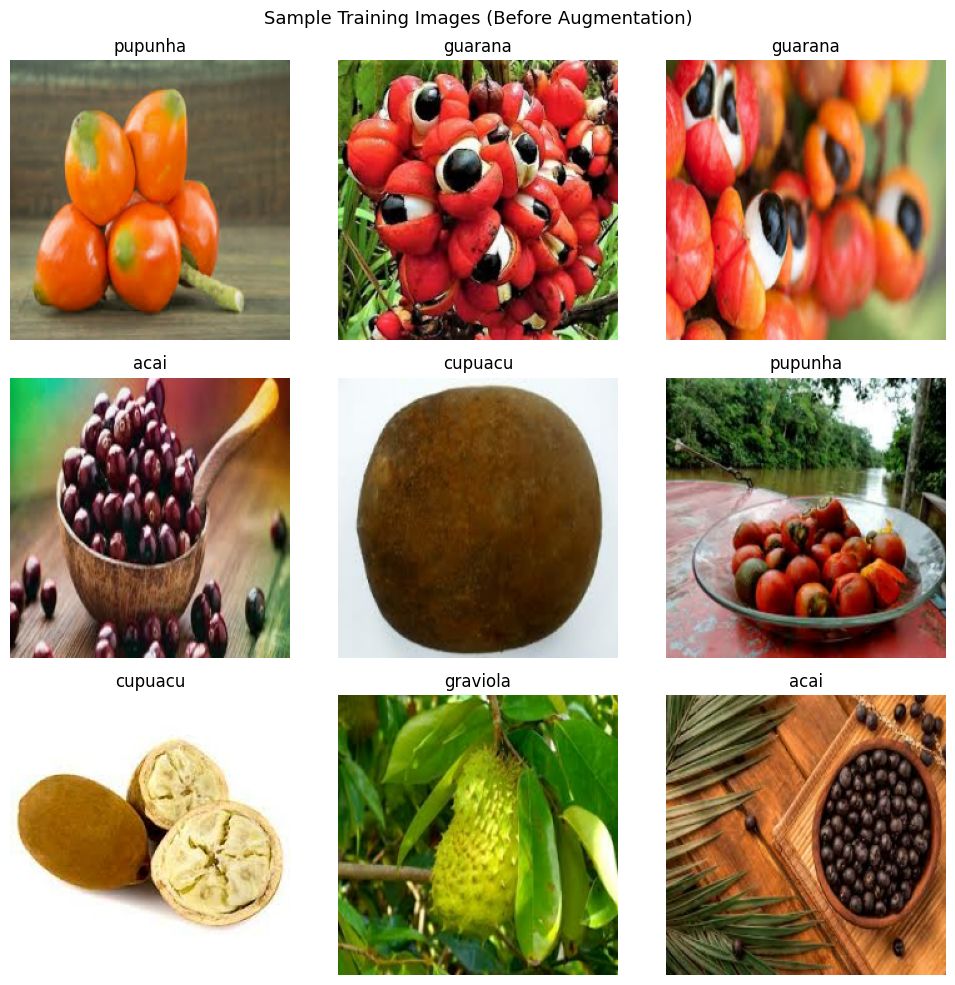

In [ ]:
# Visualise One Batch from the Training Dataset
#
# Shows the first 9 images with their integer class labels.
# Helps confirm images are loading correctly.

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):  # Take ONE batch
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))  # Convert tensor - numpy uint8
        plt.title(class_names[int(labels[i])])            # Map integer label - class name
        plt.axis("off")

plt.suptitle("Sample Training Images (Before Augmentation)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Define Data Augmentation Layers (New Keras API)
#
# RandomFlip   - mirrors images horizontally at random
# RandomRotation - rotates images by up to ±10% of 2π radians
# RandomZoom   - randomly zooms in/out by up to 20%
# RandomContrast - randomly changes image contrast
#
# These layers are applied ONLY during training (fit()),
# not during evaluation or inference.

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),       # Flip left - right
    layers.RandomRotation(0.1),            # Rotate by up to 36 degree
    layers.RandomZoom(0.2),                # Zoom in/out by 20%
    layers.RandomContrast(0.2),            # Adjust contrast by 20%
]

def data_augmentation(images):
    """Apply all augmentation layers sequentially to a batch of images."""
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

print("Data augmentation function defined with", len(data_augmentation_layers), "transformations.")

Data augmentation function defined with 4 transformations.


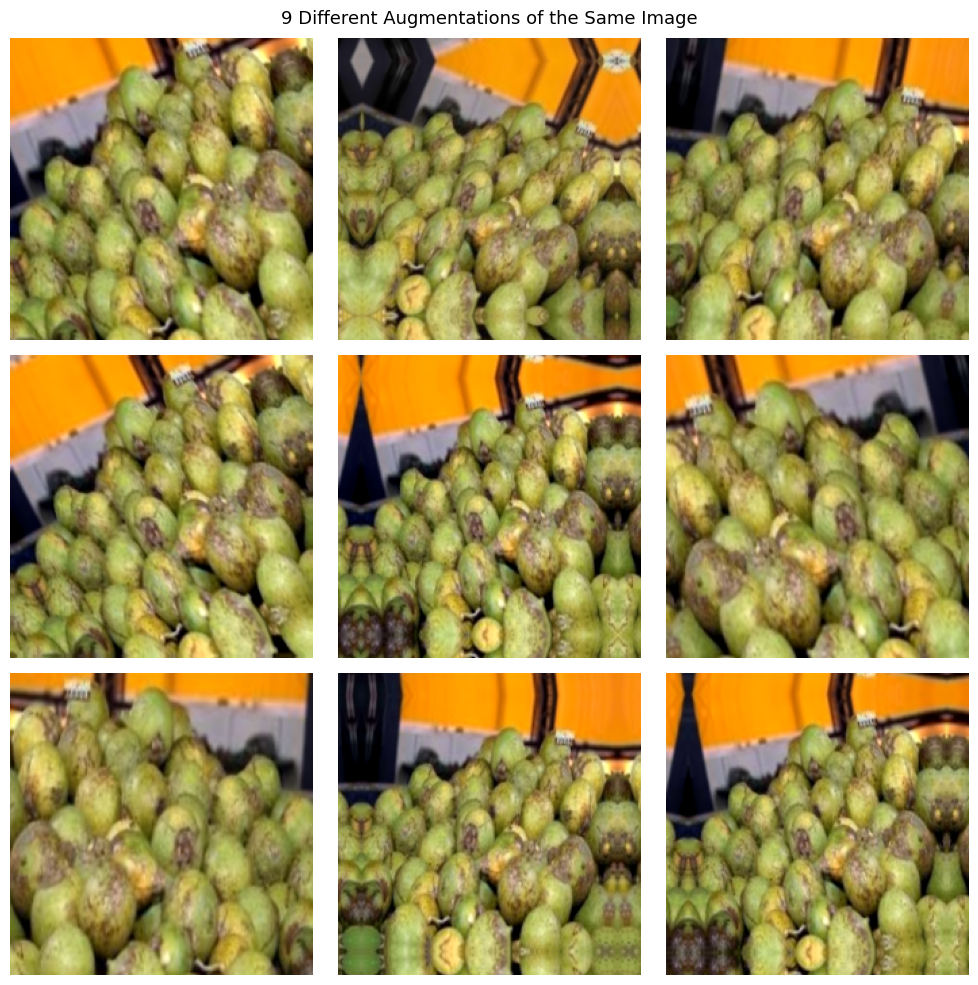

In [ ]:
# Visualise Augmented Images
#
# We take ONE image and display 9 different augmented versions
# to confirm the augmentation pipeline is working as expected.

plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):  # Take ONE batch
    for i in range(9):
        augmented_images = data_augmentation(images)       # Apply augmentations
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))  # Show first image in batch
        plt.axis("off")

plt.suptitle("9 Different Augmentations of the Same Image", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# BUILD THE IMPROVED CNN MODEL
#
# Architecture overview:
#   Input - Augmentation - Rescaling
#   - 4× [Conv2D - BN - ReLU - MaxPool - Dropout]
#   - Flatten
#   - 4× [Dense - BN - ReLU - Dropout]
#   - Output (softmax)
#
# Key design decisions:
#   • Conv filters double at each block (32 - 64 - 128 - 256)
#     to capture increasingly complex features.
#   • BatchNorm is placed BEFORE ReLU for stable gradient flow.
#   • Dropout(0.25) after conv blocks prevents spatial overfitting.
#   • Dropout(0.5) after dense layers prevents over-memorisation.


input_shape = (IMAGE_SIZE[0], IMAGE_SIZE[1], 3)  # (224, 224, 3)

model_scratch = Sequential([

    # Input
    layers.Input(shape=input_shape),

    # Data Augmentation (only active during fit())
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),

    # Rescaling: [0, 255] - [0, 1]
    # Placed INSIDE the model so it runs on GPU and is applied
    # to both original and augmented images automatically.
    layers.Rescaling(1.0 / 255),

    # Convolutional Block 1
    # 32 filters - captures low-level features (edges, colours)
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),   # Normalise activations
    Activation('relu'),     # Apply non-linearity after BN
    MaxPooling2D((2, 2)),   # Reduce spatial size by ×2
    Dropout(0.25),          # Drop 25% of feature maps

    # Convolutional Block 2
    # 64 filters - captures mid-level features (textures, shapes)
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Convolutional Block 3
    # 128 filters - captures higher-level patterns
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Convolutional Block 4
    # 256 filters - captures the most complex features
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    #  Flatten
    # Convert 3D feature maps - 1D vector for dense layers
    Flatten(),

    #  Fully Connected Block 1
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),  # Heavy dropout in dense layers

    #  Fully Connected Block 2
    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    #  Fully Connected Block 3
    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    #  Fully Connected Block 4
    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    #  Output Layer
    # NUM_CLASSES neurons with softmax - probability per class
    Dense(NUM_CLASSES, activation='softmax')
])

#  Compile
# Adam    - adaptive learning-rate optimiser
# sparse_categorical_crossentropy - integer labels (not one-hot)
# accuracy - standard classification metric
model_scratch.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print a full layer-by-layer summary (output shapes + parameters)
model_scratch.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_7 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_7               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_7 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [ ]:

# TRAIN THE SCRATCH MODEL
#
# Callbacks used:
#   EarlyStopping  - stops training when val_accuracy stops
#                    improving (patience=5), restores the best weights
#   ReduceLROnPlateau - halves the learning rate if val_loss
#                       stagnates for 3 epochs


from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Stop training early if the model stops improving
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,                  # Wait 5 epochs before stopping
    restore_best_weights=True,   # Roll back to the best epoch
    verbose=1
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # Multiply LR by 0.5
    patience=3,      # Wait 3 epochs before reducing
    min_lr=1e-6,     # Do not reduce below this value
    verbose=1
)

EPOCHS = 30  # Maximum epochs (early stopping may end training sooner)

history_scratch = model_scratch.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stopping, reduce_lr]
)

print("\nTraining complete!")

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 6s/step - accuracy: 0.0556 - loss: 2.7247 - val_accuracy: 0.0556 - val_loss: 1.8391 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.1806 - loss: 2.3360 - val_accuracy: 0.1111 - val_loss: 1.8278 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.3056 - loss: 2.1475 - val_accuracy: 0.0556 - val_loss: 1.8433 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 6s/step - accuracy: 0.1667 - loss: 2.6391 - val_accuracy: 0.0556 - val_loss: 1.8828 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1997 - loss: 2.4593
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.2083 - loss: 2.4573 - val_accuracy: 0.0556 - val_loss: 1.9189 - learning_rate: 0.0010
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.1667 - loss: 2.1257 - val_accuracy: 0.1111 - val_los

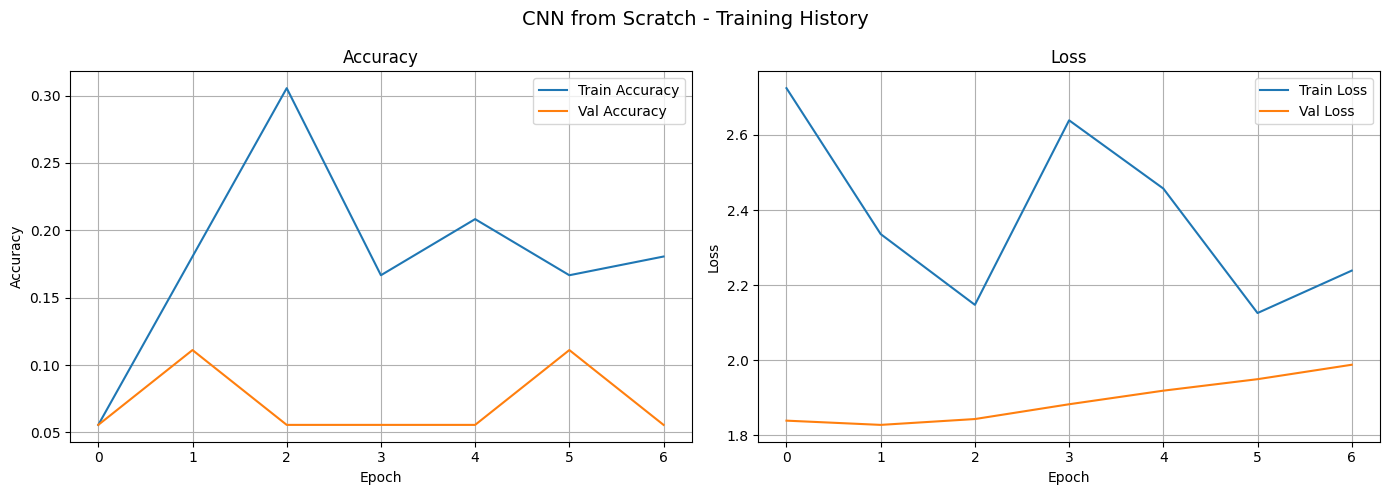

In [ ]:

# PLOT TRAINING HISTORY - Accuracy & Loss Curves
#
# These plots help us understand:
#   - Is the model learning? (accuracy increasing)
#   - Is it overfitting? (large gap between train and val curves)
#   - Did the model converge? (curves flattening out)


def plot_history(history, title="Training History"):
    """Plot accuracy and loss curves for train and validation sets."""
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    axes[0].plot(epochs_range, acc,     label='Train Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Val Accuracy')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss plot
    axes[1].plot(epochs_range, loss,     label='Train Loss')
    axes[1].plot(epochs_range, val_loss, label='Val Loss')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_history(history_scratch, title="CNN from Scratch - Training History")

In [ ]:

# EVALUATE THE SCRATCH MODEL ON THE VALIDATION SET
#
# model.evaluate() runs a full forward pass on val_ds and
# returns the final loss and accuracy metrics.
# Augmentation is NOT applied here (only during fit).


val_loss_scratch, val_acc_scratch = model_scratch.evaluate(val_ds, verbose=1)
print(f"\nScratch Model - Validation Loss    : {val_loss_scratch:.4f}")
print(f"Scratch Model - Validation Accuracy: {val_acc_scratch:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 817ms/step - accuracy: 0.1111 - loss: 1.8278

Scratch Model - Validation Loss    : 1.8278
Scratch Model - Validation Accuracy: 0.1111


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


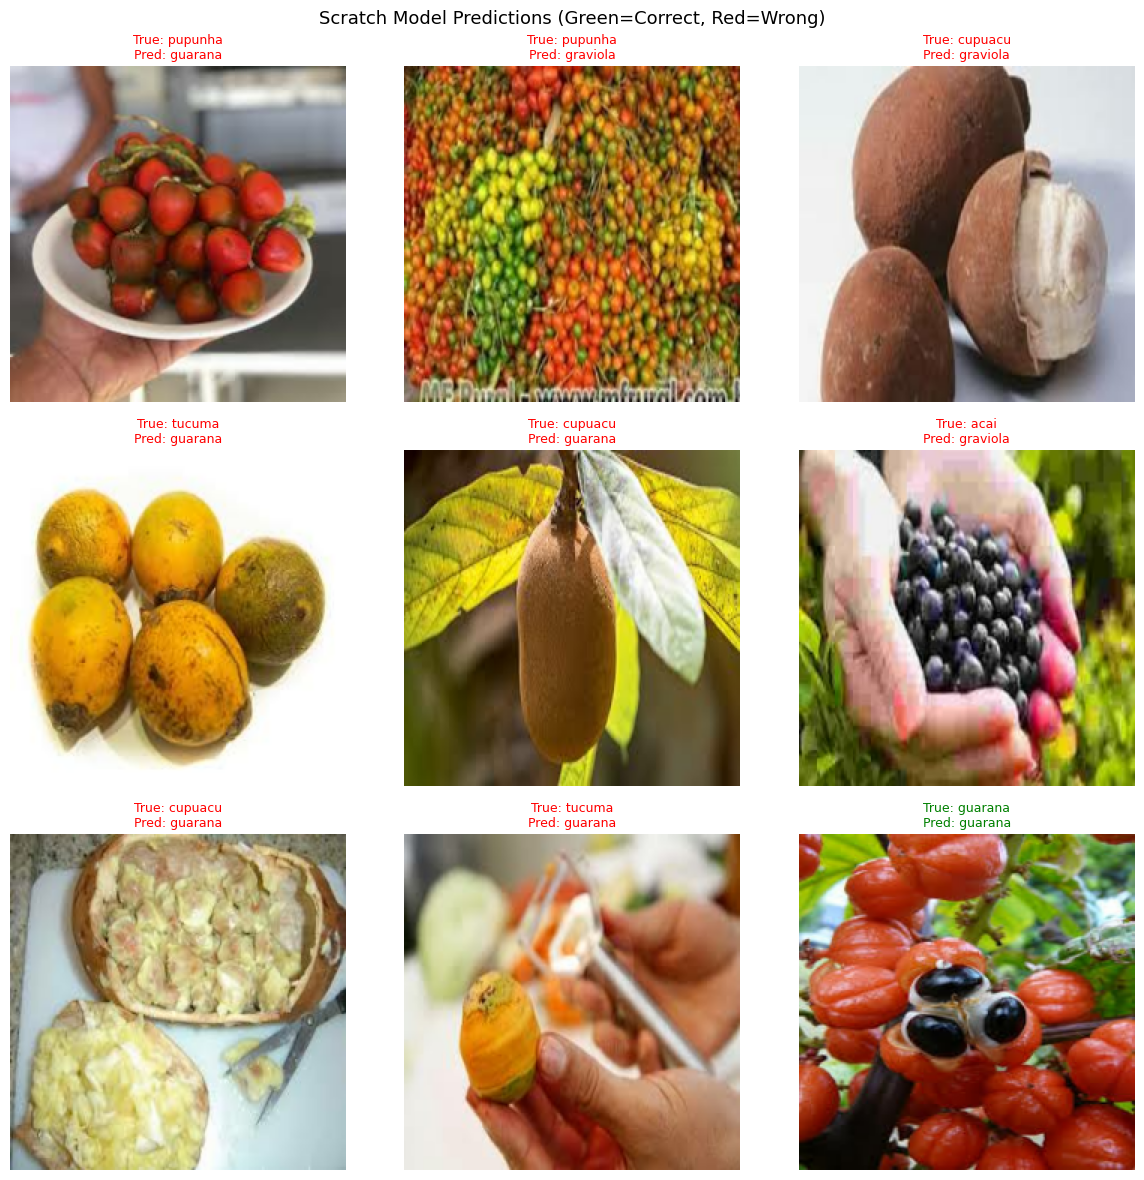

In [ ]:

# MAKE PREDICTIONS & SHOW SAMPLE RESULTS
#
# model.predict() returns a probability distribution over all
# classes for each image. np.argmax picks the highest one.


# Collect all images and true labels from the validation set
all_images_val = []
all_labels_val = []
for imgs, lbls in val_ds:
    all_images_val.append(imgs.numpy())
    all_labels_val.append(lbls.numpy())

all_images_val = np.concatenate(all_images_val, axis=0)  # Shape: (N, 224, 224, 3)
all_labels_val = np.concatenate(all_labels_val, axis=0)  # Shape: (N,)

# Run predictions
predictions_scratch = model_scratch.predict(val_ds)
predicted_classes_scratch = np.argmax(predictions_scratch, axis=1)  # Highest-probability class

#  Visualise 9 sample predictions
plt.figure(figsize=(12, 12))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(all_images_val[i].astype("uint8"))

    true_label = class_names[all_labels_val[i]]
    pred_label = class_names[predicted_classes_scratch[i]]
    colour = "green" if true_label == pred_label else "red"

    # Green title = correct, Red title = incorrect
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=colour, fontsize=9)
    plt.axis("off")

plt.suptitle("Scratch Model Predictions (Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:

# SAVE THE SCRATCH MODEL
#
# Saving lets us reload the model later for inference without
# having to retrain. The .keras format saves architecture,
# weights, and optimiser state.


model_scratch.save("cnn_scratch_model.keras")
print("Scratch model saved as 'cnn_scratch_model.keras'")

# To reload later:
# loaded_model = keras.models.load_model("cnn_scratch_model.keras")

Scratch model saved as 'cnn_scratch_model.keras'


In [ ]:

# STEP 1: Load VGG16 Pre-trained on ImageNet (without top layers)
#
# weights='imagenet'  - use ImageNet pre-trained weights
# include_top=False   - exclude the final 3 dense layers
#                       so we can add our own
# input_shape=(224,224,3) - VGG16's expected input size


base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

print(f"VGG16 base model loaded.")
print(f"Number of layers in VGG16: {len(base_model.layers)}")

# Inspect the base model architecture
base_model.summary()

VGG16 base model loaded.
Number of layers in VGG16: 19


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# STEP 2: Freeze All Layers in the Base Model
#
# Setting layer.trainable = False means the layer's weights
# will NOT be updated during back-propagation.
# This preserves the valuable ImageNet feature representations.


for layer in base_model.layers:
    layer.trainable = False  # Freeze: do not update weights

# Verify: count trainable vs non-trainable parameters
trainable_params     = sum(tf.size(w).numpy() for w in base_model.trainable_weights)
non_trainable_params = sum(tf.size(w).numpy() for w in base_model.non_trainable_weights)

print(f"Trainable parameters     : {trainable_params:,}")
print(f"Non-trainable parameters : {non_trainable_params:,}")
print("All VGG16 layers frozen. Only the new head will be trained.")

Trainable parameters     : 0
Non-trainable parameters : 14,714,688
All VGG16 layers frozen. Only the new head will be trained.


In [ ]:

# STEP 3: Add Pre-processing + Custom Classification Head
#
# VGG16 was originally trained with images normalised using
# ImageNet mean/std. We add a Rescaling layer to normalise.
#
# Custom head:
#   GlobalAveragePooling2D - collapses (H, W, C) - (C,)
#                            fewer params than Flatten
#   Dense(1024, relu)      - large FC layer for feature mixing
#   Dropout(0.5)           - regularisation
#   Dense(512, relu)       - intermediate FC layer
#   Dropout(0.5)
#   Dense(NUM_CLASSES, softmax) - final classification


# Start from the VGG16 base model input
inputs = keras.Input(shape=(224, 224, 3))

# Rescale pixel values [0,255] - [0,1]
x = layers.Rescaling(1.0 / 255)(inputs)

# Pass through frozen VGG16 convolutional layers
# training=False ensures BatchNorm layers in base run in inference mode
x = base_model(x, training=False)

# Global Average Pooling - summarises each feature map into one value
# Output shape: (batch, 512) for VGG16
x = GlobalAveragePooling2D()(x)

# Custom classification head
x = Dense(1024, activation='relu')(x)  # Large FC layer
x = BatchNormalization()(x)            # Stabilise activations
x = Dropout(0.5)(x)                    # 50% dropout

x = Dense(512, activation='relu')(x)   # Intermediate FC layer
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

# Output layer: one neuron per class, softmax - probability distribution
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

print("Custom classification head added on top of VGG16.")

Custom classification head added on top of VGG16.


In [ ]:

# STEP 4: Create the Final Transfer Learning Model
#
# Model() takes explicit input and output tensors.
# This is the Functional API approach - more flexible than Sequential.


model_vgg16 = Model(inputs=inputs, outputs=outputs)

# Summary shows which layers are trainable (the new head only)
model_vgg16.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,774,022 (60.17 MB)

 Trainable params: 1,056,262 (4.03 MB)

 Non-trainable params: 14,717,760 (56.14 MB)

In [ ]:

# STEP 5: Compile the Transfer Learning Model
#
# We use a LOW learning rate (1e-4) because:
#   - We only train the new head layers
#   - Too high an LR would overshoot and damage the head
#
# categorical_crossentropy is used here with one-hot labels.
# Note: image_dataset_from_directory returns INTEGER labels,
# so we switch to sparse_categorical_crossentropy to match.


model_vgg16.compile(
    optimizer=Adam(learning_rate=1e-4),     # Small LR for fine-tuning
    loss='sparse_categorical_crossentropy', # Integer labels
    metrics=['accuracy']
)

print("VGG16 transfer learning model compiled.")

VGG16 transfer learning model compiled.


In [ ]:

# STEP 6: Train the Transfer Learning Model
#
# Only the custom head is trained here (base is frozen).
# We reuse the same callbacks from Task 1.


early_stopping_vgg = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_vgg = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

EPOCHS_VGG = 20  # Fewer epochs needed - powerful pre-trained features

history_vgg = model_vgg16.fit(
    train_ds,
    epochs=EPOCHS_VGG,
    validation_data=val_ds,
    callbacks=[early_stopping_vgg, reduce_lr_vgg]
)

print("\nVGG16 transfer learning training complete!")

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 61s 19s/step - accuracy: 0.1528 - loss: 3.0149 - val_accuracy: 0.2222 - val_loss: 1.9057 - learning_rate: 1.0000e-04
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 23s/step - accuracy: 0.2500 - loss: 2.9131 - val_accuracy: 0.1111 - val_loss: 1.9032 - learning_rate: 1.0000e-04
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 73s 18s/step - accuracy: 0.3472 - loss: 1.9889 - val_accuracy: 0.1111 - val_loss: 1.8993 - learning_rate: 1.0000e-04
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 18s/step - accuracy: 0.3750 - loss: 2.0727 - val_accuracy: 0.0556 - val_loss: 1.8937 - learning_rate: 1.0000e-04
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 22s/step - accuracy: 0.4167 - loss: 1.4905 - val_accuracy: 0.1111 - val_loss: 1.8900 - learning_rate: 1.0000e-04
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 73s 18s/step - accuracy: 0.5556 - loss: 1.4020 - val_accuracy: 0.0556 - val_loss: 1.8871 - learning_rate: 1.0000e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.

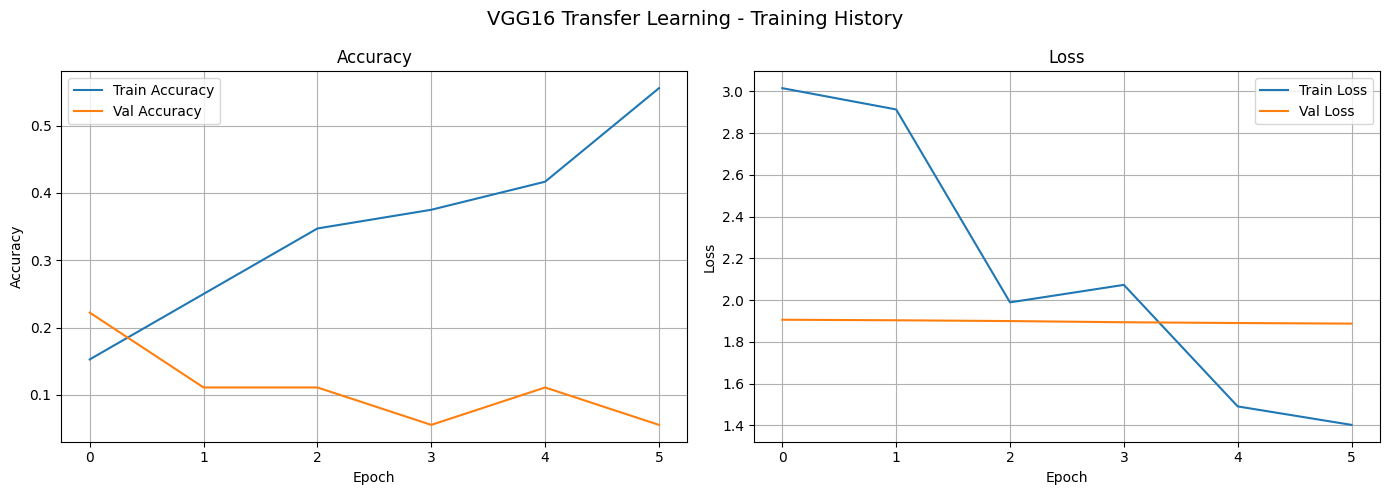

In [ ]:

# PLOT VGG16 TRAINING HISTORY
plot_history(history_vgg, title="VGG16 Transfer Learning - Training History")

In [ ]:

# EVALUATE VGG16 MODEL ON VALIDATION SET
val_loss_vgg, val_acc_vgg = model_vgg16.evaluate(val_ds, verbose=1)
print(f"\nVGG16 Model - Validation Loss    : {val_loss_vgg:.4f}")
print(f"VGG16 Model - Validation Accuracy: {val_acc_vgg:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.2222 - loss: 1.9057

VGG16 Model - Validation Loss    : 1.9057
VGG16 Model - Validation Accuracy: 0.2222


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


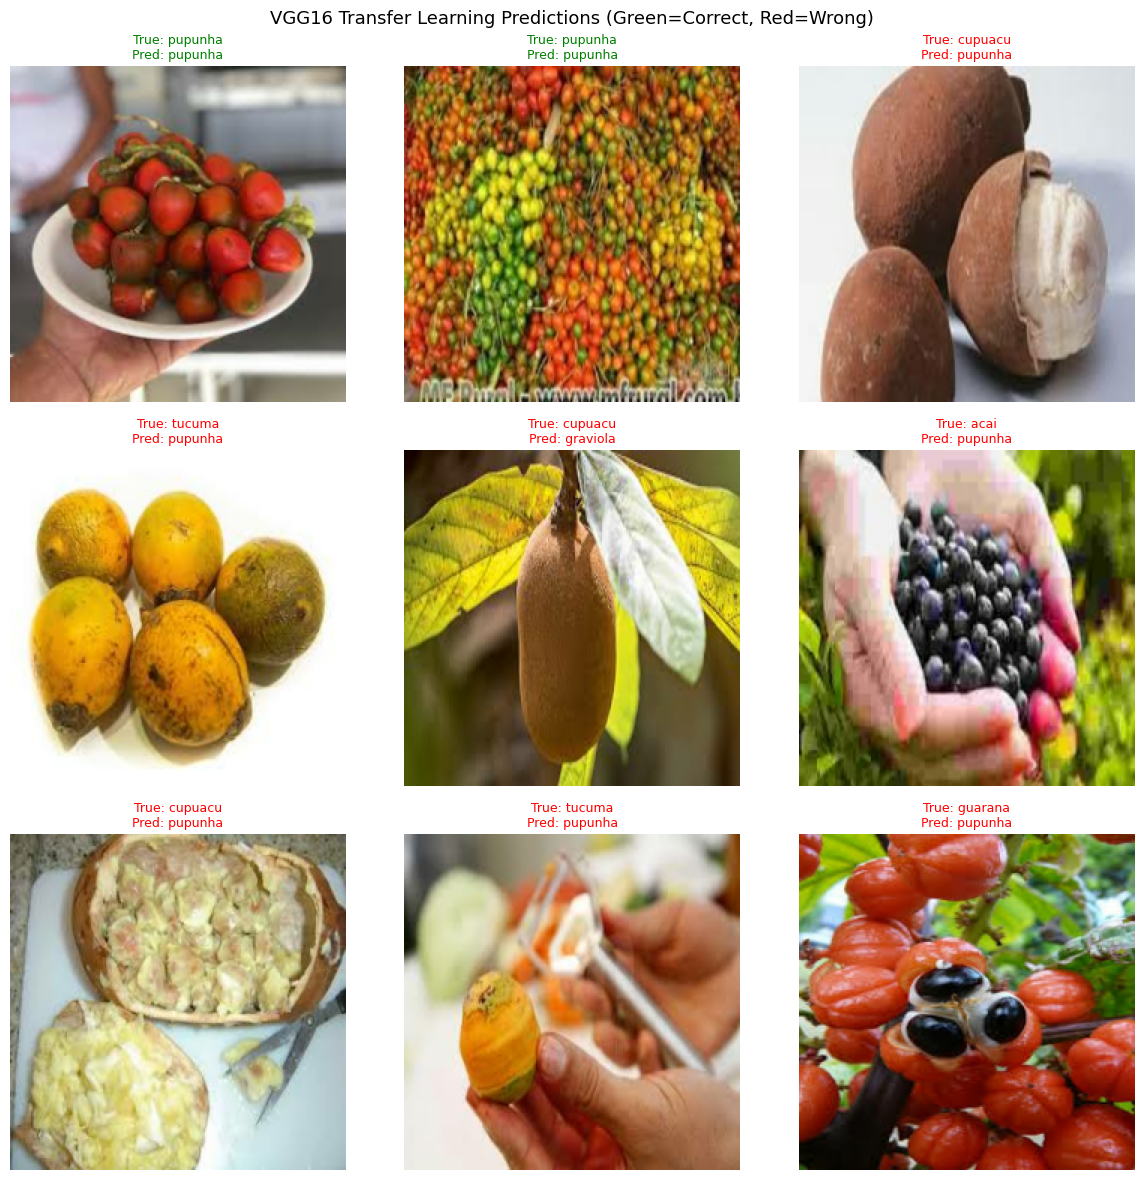

In [ ]:

# INFERENCE - Predict Class Labels for the Validation Set
#
# model.predict() returns class probabilities.
# np.argmax selects the highest-probability class index.
# We then map the index back to the human-readable class name.


# Get predictions from VGG16 model
predictions_vgg = model_vgg16.predict(val_ds)
predicted_classes_vgg = np.argmax(predictions_vgg, axis=1)

# Visualise 9 sample VGG16 predictions
plt.figure(figsize=(12, 12))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(all_images_val[i].astype("uint8"))

    true_label = class_names[all_labels_val[i]]
    pred_label = class_names[predicted_classes_vgg[i]]
    colour = "green" if true_label == pred_label else "red"

    plt.title(f"True: {true_label}\nPred: {pred_label}", color=colour, fontsize=9)
    plt.axis("off")

plt.suptitle("VGG16 Transfer Learning Predictions (Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:

# CLASSIFICATION REPORT
#
# sklearn's classification_report gives per-class metrics:
#   Precision  = TP / (TP + FP)  - of all predicted as class X,
#                                  how many were actually X?
#   Recall     = TP / (TP + FN)  - of all actual class X,
#                                  how many did we correctly find?
#   F1-score   = harmonic mean of Precision and Recall
#   Support    = number of true samples for each class


print("CLASSIFICATION REPORT - VGG16 Transfer Learning")

print(classification_report(
    all_labels_val,
    predicted_classes_vgg,
    target_names=class_names
))

CLASSIFICATION REPORT - VGG16 Transfer Learning
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.00      0.00      0.00         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.24      1.00      0.38         4
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.22        18
   macro avg       0.04      0.17      0.06        18
weighted avg       0.05      0.22      0.08        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


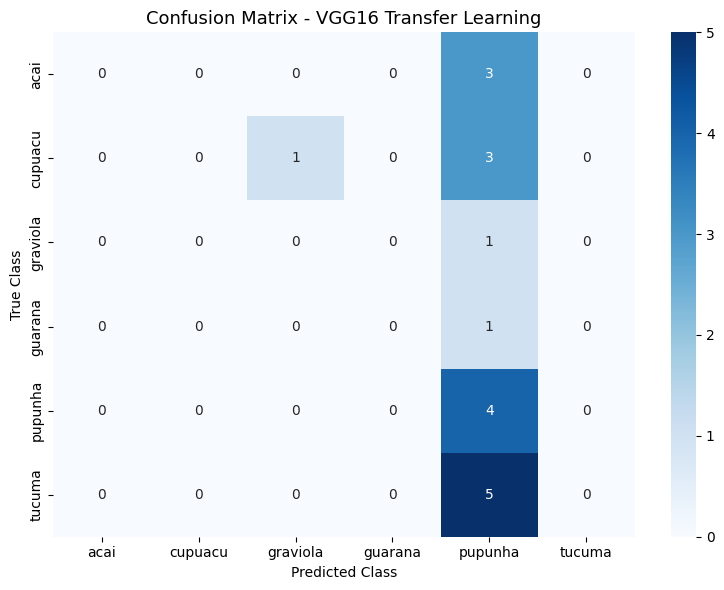

In [ ]:

# CONFUSION MATRIX
#
# A confusion matrix shows which classes are confused with
# each other. Diagonal = correct predictions.
# Off-diagonal = misclassifications.


from sklearn.metrics import confusion_matrix
import seaborn as sns  # For a nicer heatmap visualisation

cm = confusion_matrix(all_labels_val, predicted_classes_vgg)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,         # Show numbers in each cell
    fmt='d',            # Integer format
    cmap='Blues',       # Colour scheme
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix - VGG16 Transfer Learning", fontsize=13)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

In [ ]:

# SAVE THE VGG16 MODE
model_vgg16.save("vgg16_transfer_learning_model.keras")
print("VGG16 model saved as 'vgg16_transfer_learning_model.keras'")

VGG16 model saved as 'vgg16_transfer_learning_model.keras'


Model                            Val Loss    Val Acc
CNN from Scratch                   1.8278     0.1111
VGG16 Transfer Learning            1.9057     0.2222


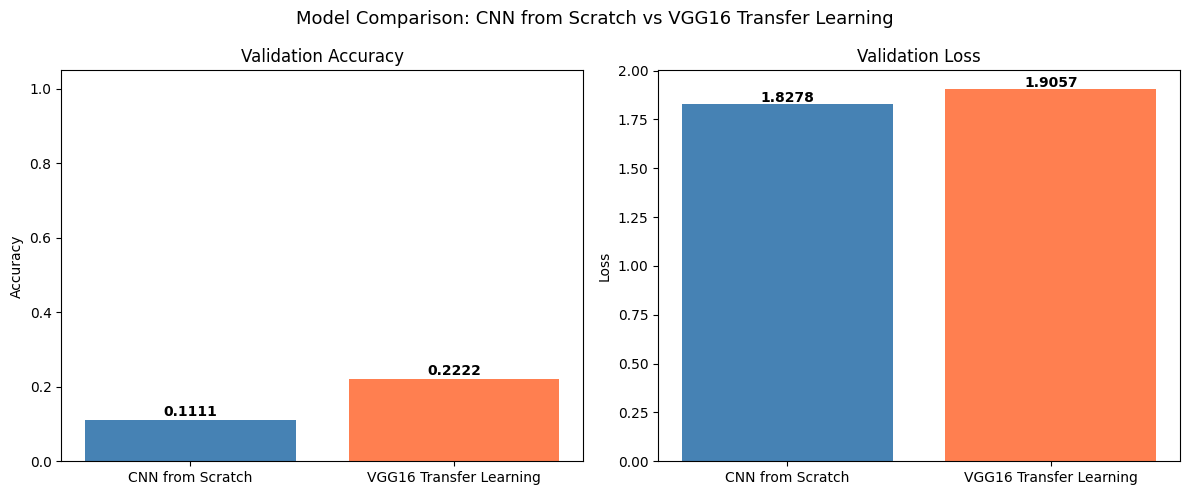


 VGG16 Transfer Learning improved accuracy by 11.11% over the scratch model.
   This confirms that pre-trained features generalise well even on small datasets.


In [ ]:

# PERFORMANCE COMPARISON
#
# We compare both models side-by-side on:
#   - Validation Accuracy
#   - Validation Loss
#
# Expected outcome:
#   VGG16 transfer learning should significantly outperform
#   the scratch model, especially on a small dataset like
#   FruitsInAmazon (only 15 images per class).


print(f"{'Model':<30} {'Val Loss':>10} {'Val Acc':>10}")
print(f"{'CNN from Scratch':<30} {val_loss_scratch:>10.4f} {val_acc_scratch:>10.4f}")
print(f"{'VGG16 Transfer Learning':<30} {val_loss_vgg:>10.4f} {val_acc_vgg:>10.4f}")

# Visual comparison bar chart
models    = ['CNN from Scratch', 'VGG16 Transfer Learning']
val_accs  = [val_acc_scratch, val_acc_vgg]
val_losses = [val_loss_scratch, val_loss_vgg]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(models, val_accs, color=['steelblue', 'coral'])
axes[0].set_title('Validation Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1.05])
for i, v in enumerate(val_accs):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

axes[1].bar(models, val_losses, color=['steelblue', 'coral'])
axes[1].set_title('Validation Loss')
axes[1].set_ylabel('Loss')
for i, v in enumerate(val_losses):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

plt.suptitle("Model Comparison: CNN from Scratch vs VGG16 Transfer Learning", fontsize=13)
plt.tight_layout()
plt.show()

# Conclusion
if val_acc_vgg > val_acc_scratch:
    improvement = (val_acc_vgg - val_acc_scratch) * 100
    print(f"\n VGG16 Transfer Learning improved accuracy by {improvement:.2f}% over the scratch model.")
    print("   This confirms that pre-trained features generalise well even on small datasets.")
else:
    print("\n The scratch model performed comparably. Consider more fine-tuning epochs for VGG16.")